# Mediznische Hochschule Hannover - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS fak_name,
                        'Medizinische Hochschule Hannover' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202603` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202603` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/00f2yqf98' -- 'Medizinische Hochschule Hannover'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Medizinische Hochschule Hannover,"Core Facility Proteomics, Hannover Medical Sch...",https://openalex.org/W4223433607
1,not assigned,Medizinische Hochschule Hannover,"Institute of Toxicology, Hannover Medical Scho...",https://openalex.org/W4223433607
2,not assigned,Medizinische Hochschule Hannover,"Department of Cardiothoracic, Transplantation ...",https://openalex.org/W4210315754
3,not assigned,Medizinische Hochschule Hannover,"Department of Dermatology, Venereology, Allerg...",https://openalex.org/W4282022649
4,not assigned,Medizinische Hochschule Hannover,"Hannover Medical School, Germany",https://openalex.org/W4214714238


In [30]:
MAPPING_DICT = {
    'Exzellenzcluster RESIST': ['resist'],
    'Forschungs- und Lehreinheit Hebammenwissenschaft': ['hebammenwissenschaft', 'midwifery'],
    'Hannover Biomedical Research School': ['biomedical research'],
    'Hannover Unified Biobank (HUB)': ['biobank'],
    'Institut für Allgemeinmedizin und Palliativmedizin': ['palliativ', 'allgemeinmedizin', 'general practice'],
    'Institut für Molekulare Bakteriologie': ['bacteriology'],
    'Institut für Molekulare und Translationale Therapiestrategien': ['therapeutic strategies'],
    'Institut für Sportmedizin': ['sport(s)?(\s)?medi(z|c)in(e)?'],
    'Institut für Transplantationsimmunologie': ['transplant(ation)? immunology'],
    'Institut für Zelltherapeutika': ['(ctc)', 'cellular therapeutics'],
    #'Integriertes Forschungs- und Behandlungszentrum Transplantation (IFB-Tx)': [],
    #'Interdisziplinäres Zentrum für Gesichtsfehlbildungen': [],
    'Klinik für Anästhesiologie und Intensivmedizin': ['an(e|ae|ä)sthesiolog(ie|y)', 'intensivmedizin'],
    'Klinik für Dermatologie, Allergologie und Venerologie': ['dermatolog(ie|y)', 'allergy(?!\sand neonatology)'],
    'Klinik für Frauenheilkunde und Geburtshilfe': ['obstetrics', 'rehabilitati(ve|on)(?!s- und sport)', 
                                                    'gyn(ae|e|ä)(k|c)olog(ie|y|ist)', 'frauen(heilkunde|klinik)'],
    'Klinik für Pneumologie und Infektiologie': ['pulmon(ology|ary)'],
    #'Klinik für Rehabilitationsmedizin': [],
    #'Kopf-Hals-Tumorzentrum Hannover': [],
    'Leibniz Forschungslaboratorien für Biotechnologie und künstliche Organe (LEBAO)': ['(lebao)'],
    'REBIRTH - Forschungszentrum für translationale regenerative Medizin': ['regenerative', 'rebirth( excellence )?cluster'],
    'Research Core Unit for Laser Microscopy': ['laser microscopy'],
    'Twincore': ['twincore'], # selbst ergänzt
    'Zentralapotheke': ['apotheke'],
    'Zentrale Forschungseinrichtung Elektronenmikroskopie': ['electron microscopy'],
    'Zentrale Forschungseinrichtung Genomics': ['genomics'],
    #'Zentrale Forschungswerkstätten': [],
    'Zentrum Anatomie und Zellbiologie': ['applied anatomy', 'neuroanatomy'],
    'Zentrum Augenheilkunde, Hals-Nasen-Ohrenheilkunde, Phoniatrie und Pädaudiologie': ['otorhinolaryngology', 'otol(ogy|ar(yn|ny)gology)', 
                                                                                        'hals(-)?(, )?nasen', 'ophthalmology', 'hno-(klinik|heilkunde)',
                                                                                        'augen(klinik|heilkunde)', 'eye hospital', 'pediatric audiology',
                                                                                        'ohrenheilkunde'
                                                                                       ],
    'Zentrum Biochemie': ['(cell|clinical) biochemistry', 'biophysical chemistry', 'zellbiochemie'],
    'Zentrum Biometrie, Medizinische Informatik und Medizintechnik': ['informatics', 'biostatistics', 'reichertz'],
    'Zentrum Chirurgie': ['of urology', 'vas(cu|uc)lar', 'plasti(sch|c)', 'trauma', 'orthop(ae|e)dic', 'orthopädische klinik', 'unfallchirurgi(e|sche)',
                          'visceral', 'surgical', 'viszeral', 'thorax', 'kinderchirurgie', 'biomechanics', 'klinik für urologie',
                          'department of surgery', 'p(ae|e|ä)diatri(c|sche) (surgery|chirurgie)', '(cardiothoracic|transplant|thoracic) surgery'
                         ],
    #'Zentrum für Arzneimittelsicherheit (ZAS)': [],
    'Zentrum für Kinderheilkunde und Jugendmedizin': ['respiratory', 'metabolic diseases', "children('|’)s hospital", 'kinderheilkunde',
                                                      'pneumolog(ie|y)', 'kinderklinik', 'pediatric (hematology|cardiology)', 'pädiatrische hämatologie'
                                                     ],
    'Zentrum für Klinische Studien (ZKS)': ['(zks)', 'cent(re|er) for clinical trials', 'clinical trial center'],
    'Zentrum für Neurologische Medizin': ['neurolog(ie|y)', 'neuro(chirurgie|surgery)'],
    'Zentrum für Pathologie, Forensik und Genetik': ['patholog(ie|y)', 'human genetics', 'humangenetik', 'rechtsmedizin', 'legal medicine'],
    'Zentrum für Pharmakologie und Toxikologie': ['toxicology', 'pharma(k|c)olog(ie|y)', 'metabolomics'],
    'Zentrum für Radiologie': ['radiolog(ie|y)', 'radiotherapy', 'nuclear', 'radiation', 'strahlentherapie', 'nuklearmedizin'],
    'Zentrum für Seelische Gesundheit': ['psychiatr(ie|y)', 'psychosomati(k|c)', 'psychotherapy', 'neuroscience'],
    'Zentrum für Zahn-, Mund- und Kieferheilkunde': ['dentistry', 'maxillofacial', 'zahnerhaltung', 'gesichtschirurgie'],
    'Zentrum Innere Medizin': ['h(ä|e|ae)matolog(ie|y)', 'hepatolog(ie|y)', 'angiolog(ie|y)', 'rheumatolog(ie|y)', 'hochdruckerkrankungen', 
                               'hypertension', 'gastroenterology', 'nephrology', 'cardiology dept', 'department of cardiology', 'systemerkrankungen',
                               'endocrinology'
                              ],
    'Zentrum Laboratoriumsmedizin': ['virology', '(for|of) immunology', 'molecular biology', 'animal', 'transfusion medicine',
                                     'clinical chemistry', 'immunomorphology', 'versuchstierkunde', 'medical microbiology'
                                    ],
    'Zentrum Physiologie': ['neurophysiology', 'cell physiology'],
    'Zentrum Öffentliche Gesundheitspflege': ['philosoph(ie|y)', 'epidemiolog(ie|y)', 'so(z|c)iolog(ie|y)', 'social medicine', 'medical psychology',
                                              'public health', 'medizinische psychologie' 
                                             ]
}

In [31]:
with open('./mapping_tables_fak/mhh.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [32]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [33]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [34]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,None,Medizinische Hochschule Hannover,"Core Facility Proteomics, Hannover Medical Sch...",https://openalex.org/W4223433607
1,Zentrum für Pharmakologie und Toxikologie,Medizinische Hochschule Hannover,"Institute of Toxicology, Hannover Medical Scho...",https://openalex.org/W4223433607
2,Zentrum Chirurgie,Medizinische Hochschule Hannover,"Department of Cardiothoracic, Transplantation ...",https://openalex.org/W4210315754
3,"Klinik für Dermatologie, Allergologie und Vene...",Medizinische Hochschule Hannover,"Department of Dermatology, Venereology, Allerg...",https://openalex.org/W4282022649
4,None,Medizinische Hochschule Hannover,"Hannover Medical School, Germany",https://openalex.org/W4214714238
...,...,...,...,...
33419,Zentrum Physiologie,Medizinische Hochschule Hannover,"Institute for Molecular and Cell Physiology, H...",https://openalex.org/W4387336540
33420,Zentrale Forschungseinrichtung Genomics,Medizinische Hochschule Hannover,"Research Core Unit Genomics, Hannover Medical ...",https://openalex.org/W4387336540
33421,Zentrum Physiologie,Medizinische Hochschule Hannover,"Institute for Molecular and Cell Physiology, H...",https://openalex.org/W4387336540
33422,Zentrum Physiologie,Medizinische Hochschule Hannover,"Institute of Neurophysiology, Hannover Medical...",https://openalex.org/W4387336540


In [35]:
df_with_inst[df_with_inst.fak_name.isnull()].raw_affiliation_string.unique()[60:80]

array(['Medical University of Hannover, Hannover, Germany',
       'Medizinische Hochschule Hannover, Stabsstelle Sicherheit und Physik, Hannover',
       'Hannover Medical School, Braunschweig, Germany',
       'Centre for Individualized Infection medicine (CiiM), a joint venture of HZI and MHH, Hannover, Germany. luka.cicin-sain@helmholtz-hzi.de',
       'Centre for Individualized Infection medicine (CiiM), a joint venture of HZI and MHH, Hannover, Germany',
       'Medizinische Hochschule Hannover, Hals Nasen Ohren Heilkunde Hannover',
       'German Center for Infection Research, Hannover Medical School, Hannover, Germany',
       'Comprehensive Cancer Center Hannover, Claudia von Schilling Center, Hannover Medical School, Hannover, Germany',
       'Clincal Chemistry, Medizinische Hochschule Hannover, Hannover, Deutschland',
       'Medizinische Hochschule Hannover (MHH), Carl-Neuberg-Straße, Hanover, Germany, Hannover, Deutschland',
       'Hannover Medical School, Hannover, Deut

In [36]:
df_with_inst[df_with_inst.fak_name.isnull()].groupby('raw_affiliation_string')['openalex_id'].count().reset_index().sort_values(by='openalex_id', ascending=False)[100:120]

,raw_affiliation_string,openalex_id
542,"Dean's Office – Curriculum Development, Hannov...",4
190,"Center for Rare Diseases, Hannover Medical Sch...",4
489,"Comprehensive Cancer Center Hannover, Hannover...",4
1895,Medizinische Hochschule Hannover; Institut für...,4
496,"Comprehensive Cancer Center, Hannover Medical ...",4
878,"Faculty of Medicine, Medizinische Hochschule H...",4
854,Drug Commissioner of Hannover Medical School ...,4
533,"Dean's Office - Curriculum Development, Hannov...",4
969,Hannover Medical School (MHH) Hannover Germany,4
1071,"Hannover Medical School, Carl-Neuberg-Straße 1...",4


In [37]:
df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()

,fak_name,openalex_id
0,Exzellenzcluster RESIST,991
1,Forschungs- und Lehreinheit Hebammenwissenschaft,116
2,Hannover Biomedical Research School,669
3,Hannover Unified Biobank (HUB),74
4,Institut für Allgemeinmedizin und Palliativmed...,440
5,Institut für Molekulare Bakteriologie,55
6,Institut für Molekulare und Translationale The...,397
7,Institut für Sportmedizin,166
8,Institut für Transplantationsimmunologie,184
9,Institut für Zelltherapeutika,57


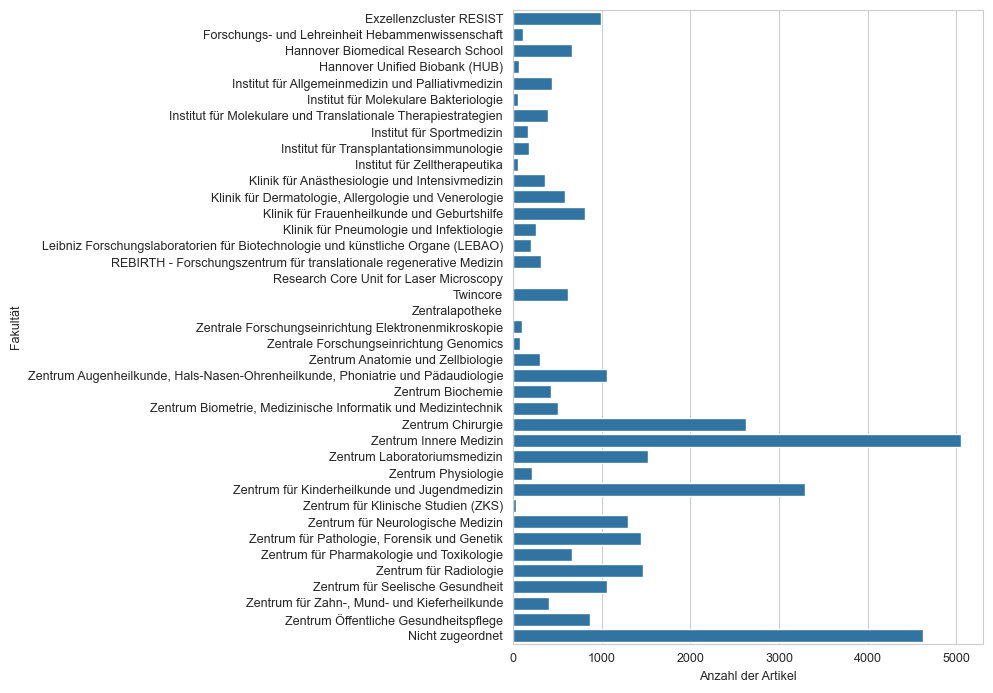

In [38]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(10, 7))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [39]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.8615665390138822

In [40]:
MAPPING_DICT_DEPT = {
    'Klinik für Dermatologie, Allergologie und Venerologie': {
        'Abteilung für Immundermatologie und experimentelle Allergologie': ['immundermatolog(ie|y)'],
    },
    'Klinik für Frauenheilkunde und Geburtshilfe': {
        'AG Biochemie und Tumorbiologie': ['tumorbiolog(ie|y)'],
        'Arbeitsgruppe Molekulare Gynäkologie': ['mole(k|c)ular'],
        'Gynäkologische Onkologie': ['gynäkologische onkologie'],
    },
    'Zentrum Anatomie und Zellbiologie': {
        'Institut für Funktionelle und Angewandte Anatomie': ['(angewandte|applied) anatom(ie|y)'],
        'Institut für Neuroanatomie und Zellbiologie': ['neuroanatom(ie|y)'],
    },
    'Zentrum Augenheilkunde, Hals-Nasen-Ohrenheilkunde, Phoniatrie und Pädaudiologie': {
        'Hals-Nasen-Ohrenklinik': ['ohren(\s)?klinik', '(dep(t.|artment)|clinic|institute) (of|for) (experimental )?(otorhinolaryngology|otolar(yn|ny)gology|otology|laryngology)', 
                                   'klinik für hals', 'hno(-|\s)klinik', 'poliklinik für hno-heilkunde', 'otorhinolaryngology department'
                                  ],
        'Klinik für Augenheilkunde': ['klinik für augenheilkunde', 'ophthalmological clinic', '(department|institute|clinic) (of|for) (experimental )?ophthalmology', 'eye hospital', 
                                      'augenklinik'],
        'Klinik für Phoniatrie und Pädaudiologie': ['klinik für phoniatrie', 'clinic of phoniatrics'],
    },
    'Zentrum Biochemie': {
        'Institut für Biophysikalische Chemie': ['biophysical', 'biophysikalische'],
        'Institut für Klinische Biochemie': ['clinical biochemistry', 'klinische biochemie'],
        'Institut für Zellbiochemie': ['cell biochemistry', 'zellbiochemie'],
    },
    'Zentrum Biometrie, Medizinische Informatik und Medizintechnik': {
        'Institut für Biometrie': ['biostatisti(k|cs)'],
        'Peter L. Reichertz Institut für Medizinische Informatik': ['reichertz', 'institute for medical informatics', 'medical informatics institute'],
    },
    'Zentrum Chirurgie': {
        'Klinik für Allgemein-, Viszeral- und Transplantationschirurgie': ['(department|clinic) (of|for) general', 'transplantation'],
        'Klinik für Herz-, Thorax-, Transplantations- und Gefäßchirurgie (HTTG)': ['cardi(ac|othor)', 'klinik für herz', 'thora(x|cic)', 'vascular', 'visceral'],
        'Klinik für Kinderchirurgie': ['kinder'],
        'Klinik für Orthopädie': ['orthop(ä|e|ae)d', 'biomechanics'],
        'Klinik für Plastische, Ästhetische, Hand- und Wiederherstellungschirurgie': ['ästhetische', 'aesthetic', 'plasti(sch|c)'],
        'Klinik für Unfallchirurgie': ['unfallchiru', 'trauma'],
        'Klinik für Urologie und Urologische Onkologie': ['on(k|c)olog(ie|y)', 'urolog(ie|y)'],
    },
    'Zentrum für Kinderheilkunde und Jugendmedizin': {
        'Klinik für Pädiatrische Hämatologie und Onkologie': ['h(ä|e|ae)matolog(ie|y)'],
        'Klinik für Pädiatrische Kardiologie und Pädiatrische Intensivmedizin': ['(k|c)ardiolog(ie|y)'],
        'Klinik für pädiatrische Nieren-, Leber- und Stoffwechselerkrankungen': ['kidney', 'stoffwechselerkrankungen'],
        'Klinik für Pädiatrische Pneumologie, Allergologie und Neonatologie': ['allergolog(ie|y)', 'pneumolog(ie|y)', 'respiratory'],
    },
    'Zentrum für Neurologische Medizin': {
        'Klinik für Neurochirurgie': ['neuro(chirurgie|surgery)'],
        'Klinik für Neurologie': ['neurolog(ie|y)'],
    },
    'Zentrum für Pathologie, Forensik und Genetik': {
        'Institut für Humangenetik': ['(dep(t|artment(s)?)|institut(e)?) (of|for|für) human(\s)?geneti(k|cs)', 'human genetics department'],
        'Institut für Pathologie': ['(dep(t|artment)|ins(t)?itut(e|ion)?|inst.) (of|for|für) (neuro)?patholog(ie|y)', 'neuropathology department'],
        'Institut für Rechtsmedizin': ['(department|institut(e)?) (of|for|für) (rechtsmedizin|legal medicine)'],
    },
    'Zentrum für Pharmakologie und Toxikologie': {
        'Institut für Klinische Pharmakologie': ['klinische pharmakologie', 'clinical pharmacology'],
        #'Institut für Pharmako- und Toxikogenomikforschung': [],
        'Institut für Pharmakologie': ['(department|institut(e)?) (of|for|für) pharma(k|c)olog(ie|y)', 'metabolomics'],
        'Institut für Toxikologie': ['(department|institut(e|es)?) (of|for|für) toxi(k|c)olog(ie|y)'],
    },
    'Zentrum für Radiologie': {
        'Institut für Diagnostische und Interventionelle Neuroradiologie': ['neuroradiolog(ie|y)'],
        'Institut für Diagnostische und Interventionelle Radiologie': ['(interv(.|entional|entionelle)|diagnosti(sche|c)) radiolog(ie|y)', 
                                                                       '(department|institut(e|es)?) (of|for|für) radiolog(ie|y)'],
        'Klinik für Nuklearmedizin': ['nuclear medicine', 'nuklearmedizin'],
        'Klinik für Strahlentherapie und Spezielle Onkologie': ['on(k|c)olog(ie|y)', 'radiotherapy', 'strahlentherapie'],
    },
    'Zentrum für Seelische Gesundheit': {
        'Klinik für Psychiatrie, Sozialpsychiatrie und Psychotherapie': ['psychiatr(ie|y)', 'neuroscience'],
        'Klinik für Psychosomatik und Psychotherapie': ['psychotherap(ie|y)', 'psychosomati(k|c)'],
    },
    'Zentrum für Zahn-, Mund- und Kieferheilkunde': {
        'Klinik für Kieferorthopädie': ['kieferorthopädie'],
        'Klinik für Mund-, Kiefer- und Gesichtschirurgie': ['maxillofacial', 'gesichtschirurgie'],
        'Klinik für Zahnerhaltung, Parodontologie und Präventivzahnmedizin': ['(conservative|preventive) dentistry', 'zahnerhaltung'],
        'Klinik für Zahnärztliche Prothetik und Biomedizinische Werkstoffkunde': ['prosthetic dentistry', 'biomedical'],
    },
    'Zentrum Innere Medizin': {
        'Institut Experimentelle Hämatologie': ['experiment(elle|al) h(ä|e|ae)matolog(ie|y)'],
        'Klinik für Gastroenterologie, Hepatologie und Endokrinologie': ['gastroenterolog(ie|y)', 'hepatolog(ie|y)'],
        'Klinik für Hämatologie, Hämostaseologie, Onkologie und Stammzelltransplantation': ['on(k|c)olog(ie|y)', 'hemostasis'],
        'Klinik für Kardiologie und Angiologie': ['(k|c)ardiolog(ie|y)'],
        'Klinik für Nieren- und Hochdruckerkrankungen': ['nieren', 'kidney', 'nephrology'],
        'Klinik für Pneumologie und Infektiologie': ['pneumologie'],
        'Klinik für Rheumatologie und Immunologie': ['rheumatolog(ie|y)', 'immunolog(ie|y)'],
    },
    'Zentrum Laboratoriumsmedizin': {
        'Institut für Immunologie': ['immunolog(ie|y)', 'immunomorphology'],
        'Institut für Klinische Chemie': ['klinische chemie', 'clinical chemistry'],
        'Institut für Medizinische Mikrobiologie und Krankenhaushygiene': ['mi(k|c)robiolog(ie|y)'],
        'Institut für Molekularbiologie': ['molecular biology'],
        'Institut für Transfusionsmedizin und Transplantat Engineering': ['transfusion'],
        'Institut für Virologie': ['virolog(ie|y)'],
        'Zentrales Tierlabor und Institut für Versuchstierkunde': ['animal (science|facility)', 'versuchstierkunde'],
    },
    'Zentrum Physiologie': {
        'Institut für Molekular- und Zellphysiologie': ['mole(k|c)ular'],
        'Institut für Neurophysiologie': ['neurophysiolog(ie|y)'],
    },
    'Zentrum Öffentliche Gesundheitspflege': {
        'Forschungs- und Lehreinheit Medizinische Psychologie': ['psycholog(ie|y)'],
        'Forschungs- und Lehreinheit Medizinische Soziologie': ['so(z|c)iolog(ie|y)'],
        'Institut für Epidemiologie, Sozialmedizin und Gesundheitssystemforschung': ['epidemiolog(ie|y)'],
        'Institut für Ethik, Geschichte und Philosophie der Medizin': ['ethi(k|cs)'],
    }
}

In [41]:
with open('./mapping_tables_dept/mhh.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_DEPT, f, ensure_ascii=False)

In [42]:
def map_dept(address: str, faculty: str) -> Union[str, None]:
    if faculty in MAPPING_DICT_DEPT:
        for k, v in MAPPING_DICT_DEPT.get(faculty).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [43]:
current_faculty = 'Zentrum Öffentliche Gesundheitspflege'

In [44]:
df_with_inst.loc[df_with_inst['fak_name'] == current_faculty, 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == current_faculty]['raw_affiliation_string'].apply(map_dept, 
                                                                                                  faculty=current_faculty)

In [45]:
df_with_inst[(df_with_inst['fak_name'] == current_faculty) & df_with_inst['dept_name'].isnull()].raw_affiliation_string.unique()[0:]

array(['Hannover Medical School, Center for Public Health and Healthcare, Hannover, Germany',
       'Center for Public Health and Healthcare, Hannover Medical School , Hannover, Germany',
       'Center for Public Health Care, Hannover Medical School, Hannover, Germany',
       'Hannover Medical School, Center for Public Health and Healthcare, Hannover, OE, Germany',
       'Center for Public Health and Healthcare, Hannover Medical School, Hannover, Germany',
       'Social Medicine and Health Systems Research, Hannover Medical School, Hannover, Germany',
       'Center for Public Health and Healthcare, German Center for Lung Research (DZL) / BREATH Hannover, Hannover Medical School, Hannover, Germany',
       'Centre for Public Health and Healthcare, Hannover Medical School',
       'Centre for Public Health and Healthcare, Hannover Medical School, Hannover, Germany',
       'State Association for Health and Academy for Social Medicine Lower Saxony Bremen e. V., Schillerstr. 32, 3015

In [46]:
df_with_inst[df_with_inst['fak_name'] == current_faculty].groupby(['dept_name'], dropna=False)['openalex_id'].count().reset_index()

,dept_name,openalex_id
0,Forschungs- und Lehreinheit Medizinische Psych...,205
1,Forschungs- und Lehreinheit Medizinische Sozio...,164
2,"Institut für Epidemiologie, Sozialmedizin und ...",332
3,"Institut für Ethik, Geschichte und Philosophie...",137
4,NaN,35


In [47]:
df_with_inst[df_with_inst['fak_name'] == current_faculty]

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name
82,Zentrum Öffentliche Gesundheitspflege,Medizinische Hochschule Hannover,"Department of Medical Psychology, Centre for P...",https://openalex.org/W4210785352,Forschungs- und Lehreinheit Medizinische Psych...
126,Zentrum Öffentliche Gesundheitspflege,Medizinische Hochschule Hannover,"Institut für Epidemiologie, Sozialmedizin und ...",https://openalex.org/W4292452111,"Institut für Epidemiologie, Sozialmedizin und ..."
141,Zentrum Öffentliche Gesundheitspflege,Medizinische Hochschule Hannover,"Hannover Medical School, Medical Psychology, C...",https://openalex.org/W4307903872,Forschungs- und Lehreinheit Medizinische Psych...
269,Zentrum Öffentliche Gesundheitspflege,Medizinische Hochschule Hannover,"Medizinische Psychologie, Medizinische Hochsch...",https://openalex.org/W4306719918,Forschungs- und Lehreinheit Medizinische Psych...
321,Zentrum Öffentliche Gesundheitspflege,Medizinische Hochschule Hannover,"Medizinische Hochschule Hannover, Institut für...",https://openalex.org/W4309099339,"Institut für Epidemiologie, Sozialmedizin und ..."
...,...,...,...,...,...
33221,Zentrum Öffentliche Gesundheitspflege,Medizinische Hochschule Hannover,"Department of Medical Psychology, Hannover Med...",https://openalex.org/W3016826821,Forschungs- und Lehreinheit Medizinische Psych...
33246,Zentrum Öffentliche Gesundheitspflege,Medizinische Hochschule Hannover,"Institute for Ethics, History, and Philosophy ...",https://openalex.org/W2998472634,"Institut für Ethik, Geschichte und Philosophie..."
33252,Zentrum Öffentliche Gesundheitspflege,Medizinische Hochschule Hannover,"Institute for Epidemiology, Hannover Medical S...",https://openalex.org/W3091923804,"Institut für Epidemiologie, Sozialmedizin und ..."
33282,Zentrum Öffentliche Gesundheitspflege,Medizinische Hochschule Hannover,"Hannover Medical School, Institute for Ethics,...",https://openalex.org/W3090508824,"Institut für Ethik, Geschichte und Philosophie..."


In [48]:
MAPPING_DICT_INST = {}

In [50]:
gerit_ids = pd.read_csv('../../data/gerit_inst_with_ids.csv')
gerit_ids = gerit_ids[gerit_ids.parent_name == 'Medizinische Hochschule Hannover (MHH)'][['inst_name', 'dfg_id']].to_dict(orient='records')

def search_gerit_id(name: str):  
    for gerit_id in gerit_ids:
        if gerit_id['inst_name'] == name:
            return gerit_id.get('dfg_id')

uni_dicts = dict()

for faculty, faculty_patterns in MAPPING_DICT.items():

    faculty_dict = dict()

    faculty_dict['faculty_id'] = search_gerit_id(faculty)
    faculty_dict['faculty_patterns'] = faculty_patterns

    faculty_suborganisations = dict()
    
    if MAPPING_DICT_DEPT.get(faculty):
        for department, department_patterns in MAPPING_DICT_DEPT.get(faculty).items():

            department_dict = dict()
            
            department_dict['department_id'] = search_gerit_id(department)
            department_dict['department_patterns'] = department_patterns

            department_suborganisations = dict()
            
            if MAPPING_DICT_INST.get(department):
                for institute, institute_patterns in MAPPING_DICT_INST.get(department).items():

                    institute_dict = dict()
            
                    institute_dict['institute_id'] = search_gerit_id(institute)
                    institute_dict['institute_patterns'] = institute_patterns

                    department_suborganisations[institute] = institute_dict
                    
            department_dict['suborganisations'] = department_suborganisations

            faculty_suborganisations[department] = department_dict

    faculty_dict['suborganisations'] = faculty_suborganisations

    uni_dicts[faculty] = faculty_dict

with open('../../data/mappings/mhh.json', mode='w', encoding='utf-8') as f:
    json.dump(uni_dicts, f, ensure_ascii=False)